# 01 - Data Loading, Merging and Cleaning

**Owner: Pornraksa Suksawaeng**

This notebook is the foundation of the NextBuy project. It loads the 5 raw CSV files, merges them in the correct order to minimize memory usage, investigates data quality issues, clean the dataset, and exports it as `cleaned_data.csv` for all other notebook to use.

## 0. Imports and Configurations

In [1]:
import os
import pandas as pd
import numpy as np

from itertools import combinations
from collections import Counter

from dotenv import load_dotenv
load_dotenv()

USE_S3 = os.getenv('USE_S3', 'False').lower() == 'true'
S3_BUCKET = os.getenv('S3_BUCKET', '')

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("Pandas version:", pd.__version__)


BASE_DIR: /home/admin/Documents/nextbuy/notebooks
DATA_DIR: /home/admin/Documents/nextbuy/notebooks/../data
Pandas version: 3.0.1


## 1. Load CSV Files

We load all 5 files with explicit `dtype` specifications.
The `order_products` files is the heaviest (~14M rows), so correct dtypes are critical to avoid memory crash.

In [16]:
if USE_S3:
    # NOTE: To read from S3, the AWS credentials must be configured in the environment (e.g., via AWS CLI or environment variables).
    # NOTE: Import s3fs is necessary to ensure that pandas can use the S3 filesystem, even if we don't directly use s3fs in this code.
    import s3fs
    order_products = pd.read_csv(f's3://{S3_BUCKET}/order_products.csv', 
        dtype={
            'order_id': 'Int32',
            'product_id': 'Int32',
            'add_to_cart_order': 'Int16',
            'reordered': 'Int8',
        },
    )

    products = pd.read_csv(f's3://{S3_BUCKET}/products.csv',
        dtype={
            'product_id': 'Int32',
            'aisle_id': 'Int16',
            'department_id': 'Int8',
            'product_name': 'str'
        },
    )

    aisles = pd.read_csv(f's3://{S3_BUCKET}/aisles.csv')
    departments = pd.read_csv(f's3://{S3_BUCKET}/departments.csv')

    orders = pd.read_csv(f's3://{S3_BUCKET}/orders.csv',
        dtype={
            'order_id': 'Int32',
            'user_id': 'Int32',
            'order_number': 'Int16',
            'order_dow': 'Int8',
            'order_hour_of_day': 'Int8'
        },
    )
else:
    # NOTE: When reading from local files, we can directly use the file paths. The dtypes are specified to optimize memory usage, especially for the large order_products file.
    order_products = pd.read_csv(
        os.path.join(DATA_DIR, 'order_products.csv'),
        dtype={
            'order_id': 'Int32',
            'product_id': 'Int32',
            'add_to_cart_order': 'Int16',
            'reordered': 'Int8',
        },
    )

    products = pd.read_csv(
        os.path.join(DATA_DIR, 'products.csv'),
        dtype={
            'product_id': 'Int32',
            'aisle_id': 'Int16',
            'department_id': 'Int8',
            'product_name': 'str'
        }
    )

    aisles = pd.read_csv(
        os.path.join(DATA_DIR, 'aisles.csv')
    )

    departments = pd.read_csv(
        os.path.join(DATA_DIR, 'departments.csv')
    )

    orders = pd.read_csv(
        os.path.join(DATA_DIR, 'orders.csv'),
        dtype={
            'order_id': 'Int32',
            'user_id': 'Int32',
            'order_number': 'Int16',
            'order_dow': 'Int8',
            'order_hour_of_day': 'Int8'
        }
    )

print(f'order_products: {len(order_products)} lines')
print(f'products: {len(products)} lines')
print(f'aisles: {len(aisles)} lines')
print(f'departments: {len(departments)} lines')
print(f'orders: {len(orders)} lines')

order_products: 13692886 lines
products: 49688 lines
aisles: 134 lines
departments: 21 lines
orders: 1444444 lines


## 2. Merge CSV Files 

We merge the 5 files in a specific order to minimize memory usage : `order_products` → `products` → `aisles` → `departments` → `orders`

We start from the largest file (`order_products`) and progressively enrich it with reference tables. All joins are `left` to keep every product row and reveal any unmatched keys as NaN.

In [17]:
df = (order_products
    .merge(products, on='product_id', how='left')
    .merge(aisles, on='aisle_id', how='left')
    .merge(departments, on='department_id', how='left')
    .merge(orders, on='order_id', how='left')
)

print(f'Data frame shape after merging: {df.shape[0]} lines x {df.shape[1]} columns')
df.head()

Data frame shape after merging: 13692886 lines x 14 columns


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0


## 3. Exploration and Sanity Check

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13692886 entries, 0 to 13692885
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                Int32  
 1   product_id              Int32  
 2   add_to_cart_order       Int16  
 3   reordered               Int8   
 4   product_name            object 
 5   aisle_id                Int16  
 6   department_id           Int8   
 7   aisle                   object 
 8   department              object 
 9   user_id                 Int32  
 10  order_number            Int16  
 11  order_dow               Int8   
 12  order_hour_of_day       Int8   
 13  days_since_prior_order  float64
dtypes: Int16(3), Int32(3), Int8(4), float64(1), object(3)
memory usage: 835.7+ MB


In [19]:
df.describe(include='all')

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,13692886.0,13692437.0,13692440.0,13692437.0,13692437,13692437.0,13692437.0,13692437,13692437,13692529.0,13692642.0,13692683.0,13692688.0,1.281389e+07
unique,<NA>,<NA>,<NA>,<NA>,49067,<NA>,<NA>,134,21,<NA>,<NA>,<NA>,<NA>,NaN
top,<NA>,<NA>,<NA>,<NA>,Banana,<NA>,<NA>,fresh fruits,produce,<NA>,<NA>,<NA>,<NA>,NaN
freq,<NA>,<NA>,<NA>,<NA>,199654,<NA>,<NA>,1539566,4005331,<NA>,<NA>,<NA>,<NA>,NaN
mean,1885226.378435,25572.837448,8.347785,0.58959,NaN,71.207989,9.918454,NaN,NaN,102953.236033,17.146044,2.741735,13.423868,1.110298e+01
std,964451.273232,14095.388562,7.125875,0.491908,NaN,38.204561,6.280598,NaN,NaN,59459.08848,17.537008,2.08984,4.246468,8.781552e+00
min,2.0,1.0,1.0,0.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0,0.0,0.0,0.000000e+00
25%,816826.0,13524.0,3.0,0.0,NaN,31.0,4.0,NaN,NaN,51447.0,5.0,1.0,10.0,5.000000e+00
50%,2278485.0,25246.0,6.0,1.0,NaN,83.0,9.0,NaN,NaN,102628.0,11.0,3.0,13.0,8.000000e+00
75%,2639194.0,37923.0,11.0,1.0,NaN,107.0,16.0,NaN,NaN,154406.0,24.0,5.0,16.0,1.500000e+01


Because we use `left` joins, any rows from `order_products` whose keys has no match in a reference table will produce NaN. We investigate these before deciding how to handle them.

A high number of unmatched key would suggest a merge issue. A low number suggests the raw data is simply incomplete for a few records.

In [20]:
# Check unmatched products_ids
unmatched_products = df[df['product_name'].isnull()]['product_id'].unique()
print(f'Number of unmatched product_ids: {len(unmatched_products)}')

# Check unmatched aisle_ids
unmatched_aisles = df[df['aisle'].isnull()]['aisle_id'].unique()
print(f'Number of unmatched aisle_ids: {len(unmatched_aisles)}')

Number of unmatched product_ids: 1
Number of unmatched aisle_ids: 1


In [21]:
# Check aisle_ids with missing aisle names
print(df[df['aisle'].isna()]['aisle_id'].value_counts())


Series([], Name: count, dtype: Int64)


**Findings:**
- 1 `product_id` has no match in `products.csv`, this product was ordered but has no reference data. Its rows will be dropped.

## 4. Cleaning 

Based on the sanity check above, we apply the following cleaning steps in order:
1. Drop rows with unmatched `product_id` or `order_id`, these rows are unusable
2. Handle `days_since_prior_order` NaN, these are meaningful (first order)
3. Check for duplicates
4. Verify `add_to_cart_order` sequence integrity

### 4.1 Drop Unusable rows

We drop rows where critical join keys have no match in the reference files.
These rows cannot be enriched with product or order information and would corrupt any analysis.

In [22]:
# Drop rows with missing product names, as they represent unmatched product_ids
df = df.dropna(subset=['product_name'])

# Unmatched product_id in products.csv 
df = df.dropna(subset=['add_to_cart_order', 'reordered'])

# Unmatched order_id in orders.csv
df = df.dropna(subset=['user_id', 'order_number', 'order_dow', 'order_hour_of_day'])

### 4.2 Fill missing aisle names

We attempt to recover missing aisle names by re-reading `aisles.csv` and looking up the unmatched IDs.
If the names are found, the join issue was a dtype mismatch. If not, the data is genuinely absent.

In [23]:
missing_aisles_ids = df[df['aisle'].isna()]['aisle_id'].unique()
aisles_lookup = pd.read_csv(os.path.join(DATA_DIR, 'aisles.csv'))
missing_aisles = aisles_lookup[aisles_lookup['aisle_id'].isin(missing_aisles_ids)]

print("Missing aisle_ids with their names:", missing_aisles)

Missing aisle_ids with their names: Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


### 4.3 Handle days_since_prior_order NaN

NaN in days_since_prior_order is expected and meaningful, it only occurs on a user's very first order, where there is no previous order to measure from.

We handle in two steps:
- Create a binary flag `is_first_order` to preserve information
- Fill with `0` as a neutral placeholder to satisfy dtype and ML model requirements

The `0` is not meant to be interpreted as "same day reorder", the `is_first_order` flag carries that context.

In [24]:
# before fillna
print(df['days_since_prior_order'].isna().sum())  
df['is_first_order'] = df['days_since_prior_order'].isna().astype(int)

df['days_since_prior_order'] = df['days_since_prior_order'].fillna(0).astype('float64')
print(df['days_since_prior_order'].isna().sum()) 

878860
0


### 4.4 Remove duplicates

We check for fully duplicated rows. With correct merge, there should be none, each row represent a unique product within a unique order. If duplicate exist, it signal a merge issue.

In [25]:
number_duplicate_rows = df.duplicated().sum()
print(f'Number of duplicate rows: {number_duplicate_rows}')
if number_duplicate_rows > 0:
    df = df.drop_duplicates()
    print(f'Number of duplicate rows after dropping: {df.duplicated().sum()}')

Number of duplicate rows: 0


### 4.5 Verify add_to_cart_order sequence

We verify that every order starts its cart sequence at position 1, a minimum value above 1 would suggest a missing rows in the data.

In [26]:
min_cart = df.groupby('order_id')['add_to_cart_order'].min()
print(f'Minimum value of add_to_cart_order - min global: {min_cart.min()}')
print("Correct sequence" if min_cart.min() == 1 else "Incorrect sequence")

Minimum value of add_to_cart_order - min global: 1
Correct sequence


## 5.0 Checkup before exporting

We run a final validation to confirm the dataset is clean and consistent before exporting. 

In [27]:
print(f"Rows: {df.shape[0]:,} Columns: {df.shape[1]}")

nan_counts = df.isnull().sum()
if nan_counts.sum() == 0:
    print("No NaN remaining ")
else:
    print(nan_counts[nan_counts > 0])

n_dup = df.duplicated().sum()
print(f"No duplicates" if n_dup == 0 else f"{n_dup} duplicates remaining")

print(df.dtypes)

display(df.head(10))


Rows: 13,690,540 Columns: 15
No NaN remaining 
No duplicates
order_id                    Int32
product_id                  Int32
add_to_cart_order           Int16
reordered                    Int8
product_name               object
aisle_id                    Int16
department_id                Int8
aisle                      object
department                 object
user_id                     Int32
order_number                Int16
order_dow                    Int8
order_hour_of_day            Int8
days_since_prior_order    float64
is_first_order              int64
dtype: object


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0
5,2,17794,6,1,Carrots,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
6,2,40141,7,1,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry,202279,3,5,9,8.0,0
7,2,1819,8,1,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry,202279,3,5,9,8.0,0
8,2,43668,9,0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce,202279,3,5,9,8.0,0
9,4,46842,1,0,Plain Pre-Sliced Bagels,93,3,breakfast bakery,bakery,178520,36,1,9,7.0,0


## 6.0 Export cleaned dataset

We export the cleaned dataset as `cleaned_data.csv`.

In [28]:
if USE_S3:
    import s3fs
    df.to_csv(f's3://{S3_BUCKET}/cleaned_data.csv', index=False)
    print(f'Cleaned data saved to S3 bucket: {S3_BUCKET}/cleaned_data.csv')
else:
    output_path = os.path.join(DATA_DIR, 'cleaned_data.csv')
    df.to_csv(output_path, index=False)
    print(f'Cleaned data saved to: {output_path}')

print(f'Final data frame shape: {df.shape[0]} lines x {df.shape[1]} columns')

Cleaned data saved to: /Users/pon/Desktop/dev/epitech/nextbuy/notebooks/../data/cleaned_data.csv
Final data frame shape: 13690540 lines x 15 columns


# 02 - Exploratory Data Analysis

**Owners: Pornraksa Suksawaeng**

This notebook answers 12 business questions using varied visualizations. Each chart is followed by a written analysis.

**Questions covered:**

| N | Question | Chart type | Owner |
|---|---|---|---|
| 1 | Which products are the bestsellers? | Horizontal bar | Pornraksa |
| 2 | When do customers order? (day + hour) | Heatmap | Pornraksa |
| 3 | Can we predict if a product will be reordered? | → see 03_models | Léo + Mathis |
| 4 | What are the main customer profiles? | → see 04_bonus | Nicolas |
| 5 | Which products are frequently bought together? | → see 04_bonus | Nicolas |
| 6 | Which department has the highest reorder rate? | Bar chart | Pornraksa |
| 7 | Link between days since last order and reorder rate? | Scatter plot | Pornraksa |
| 8 | What proportion of products is organic per department? | Stacked bar | Pornraksa |
| 9 | Which item do customers add to cart first? | Frequency table | Pornraksa |
| 10 | Can we predict the next cart size? | → see 03_models | Léo + Mathis |
| 11 | What is the reorder rate by hour of day? | Line chart | Pornraksa |
| 12 | Which features influence reorder prediction most? | → see 04_bonus SHAP | Nicolas |

## 0. Imports and Setup

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})

from dotenv import load_dotenv
load_dotenv()

USE_S3 = os.getenv('USE_S3', 'False').lower() == 'true'
S3_BUCKET = os.getenv('S3_BUCKET', '')

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

figures_dir = os.path.join(BASE_DIR, '..', 'figures')
os.makedirs(figures_dir, exist_ok=True)

if USE_S3:
    import s3fs
    df = pd.read_csv(f's3://{S3_BUCKET}/cleaned_data.csv')
    print(f'Dataset loaded from S3 bucket: {S3_BUCKET}/cleaned_data.csv with shape: {df.shape}')
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))
    print(f'Dataset loaded from: {os.path.join(DATA_DIR, "cleaned_data.csv")} with shape: {df.shape}')
df.head()

Dataset loaded from: /Users/pon/Desktop/dev/epitech/nextbuy/notebooks/../data/cleaned_data.csv with shape: (13690540, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,is_first_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,3,5,9,8.0,0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,3,5,9,8.0,0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,3,5,9,8.0,0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,3,5,9,8.0,0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,3,5,9,8.0,0


### Base dataframes

We define two dataframes here and reuse them throughout the notebook.


In [17]:
df_all = df.copy()

# Exclude first orders, used for any reorder rate analysis
df_reorders = df[df['is_first_order'] == 0].copy()

print(f'df_all shape: {df_all.shape}')
print(f'df_reorders shape: {df_reorders.shape}')
print(f'First orders excluded: {df_all.shape[0] - df_reorders.shape[0]} rows removed')


df_all shape: (13690540, 15)
df_reorders shape: (12811680, 15)
First orders excluded: 878860 rows removed


## Q1 - Which products are the bestsellers?

**Chart: Horizontal bar chart**

We count total order occurrences per product across the entire dataset, and a horizontal bar chart is chose because product names are long and easier to read on the y-axis.

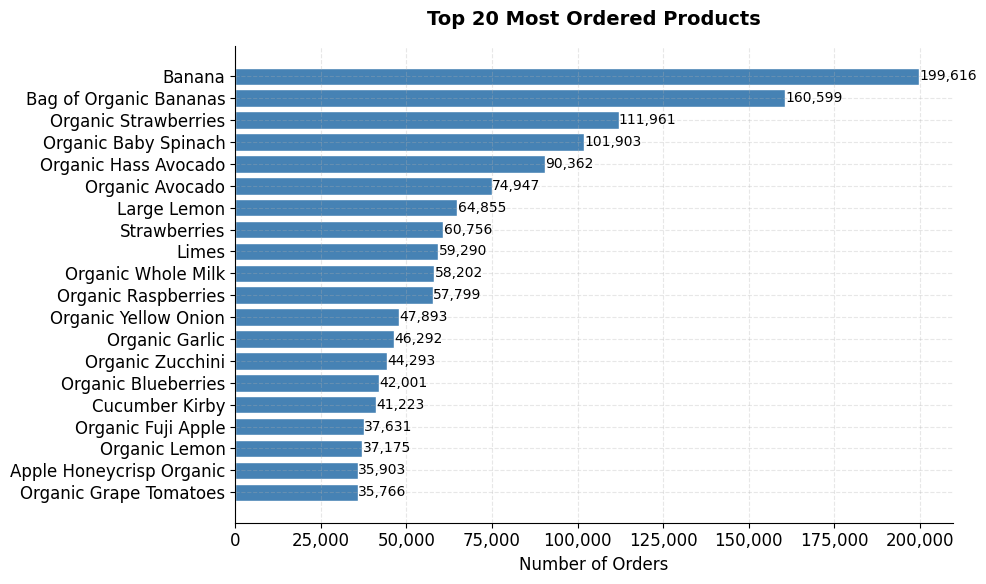

In [18]:
top_n = 20

top_products = (df_all
    .groupby('product_name')['order_id']
    .count()
    .nlargest(top_n)
    .reset_index()
    .rename(columns={'order_id': 'count'})
    .sort_values('count')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_products['product_name'], top_products['count'], color='steelblue', edgecolor='white')

ax.set_xlabel('Number of Orders')
ax.set_title(f'Top {top_n} Most Ordered Products', pad=15)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width()):,}', va='center', fontsize=10)   

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q1_bestsellers.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:**<br>
Banana leads the bestseller ranking with 199,616 orders, nearly 25% ahead of the second product Bag of Organic Bananas (160,599), confirming it as the dataset's dominant staple. The top 20 is entirely fresh produce, with 15 out of 20 products carrying the "Organic" label - no processed or packaged items appear anywhere in the list, revealing that Instacart customers skew strongly toward health-conscious, fresh-food shopping. A sales manager should prioritise stock reliability for these 20 products above all others, use them as anchor items in app promotions, and invest in organic supplier relationships - the direct competition between Banana (199,616) and Bag of Organic Bananas (160,599) suggests organic variants are on track to overtake their conventional counterparts.

## Q2 — When do customers order? (day + hour)

**Chart: Heatmap**

We aggregate unique orders by day of week and hour of day. A heatmap reveals the combinations of both dimensions simultaneously something that two separate bar chart cannot do.

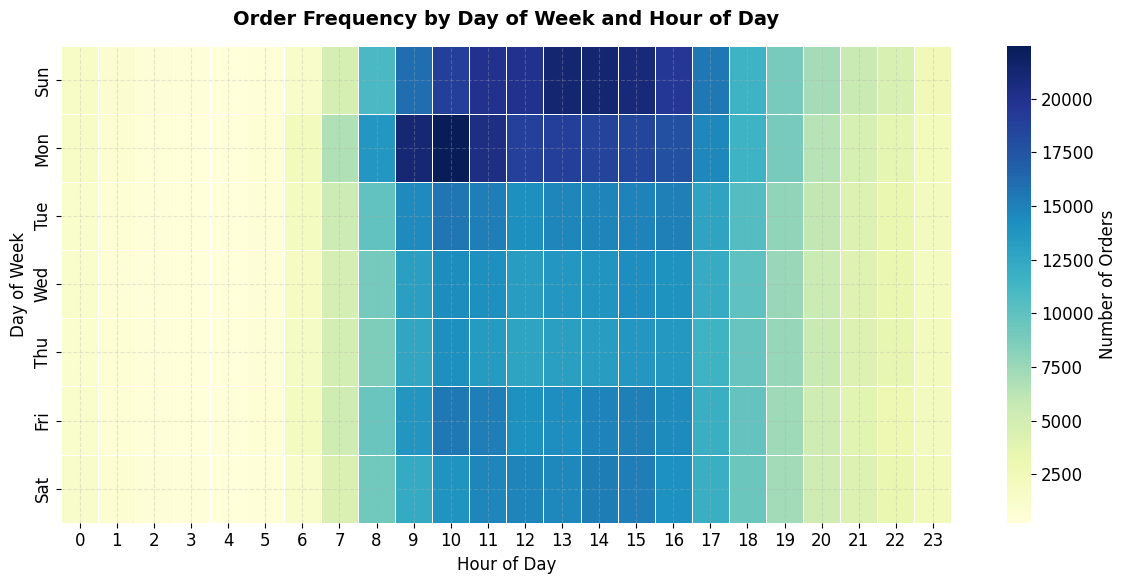

In [19]:
# Deduplicate to order level
order_dedup = df_all.drop_duplicates(subset='order_id')

pivot = order_dedup.pivot_table(
    index='order_dow',
    columns='order_hour_of_day',
    values='order_id',
    aggfunc='count'
)

# order_dow: 0=Sunday, 1=Monday, ..., 6=Saturday
day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot,
    cmap='YlGnBu',
    ax=ax,
    linewidths=0.5,
    linecolor='white',
    yticklabels=day_labels,
    cbar_kws={'label': 'Number of Orders'}
)
ax.set_title('Order Frequency by Day of Week and Hour of Day', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q2_order_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()


**Analysis:**<br>
Sunday and Monday between 9am and 6pm are the peak ordering window, with Monday 10am appearing as the single busiest slot (dark navy, ~20,000+ orders). The dead zones are clear - every night from 0am to 6am is near-zero across all days, and weekday evening after 6pm drop off significantly. A retailer should concentrate push notifications, flash promotions, and restocking operations around the Sunday–Monday morning window to capture maximum order volume, and avoid scheduling app maintenance or marketing campaigns during the 9am–4pm peak.

## Q3 - What features correlate with reorder behavior?

**Chart: Correlation heatmap**

Before building the reorder classifier, we examine which numerical features correlate most with `reordered`. This guides features selection in `03_models_leo.ipynb`.

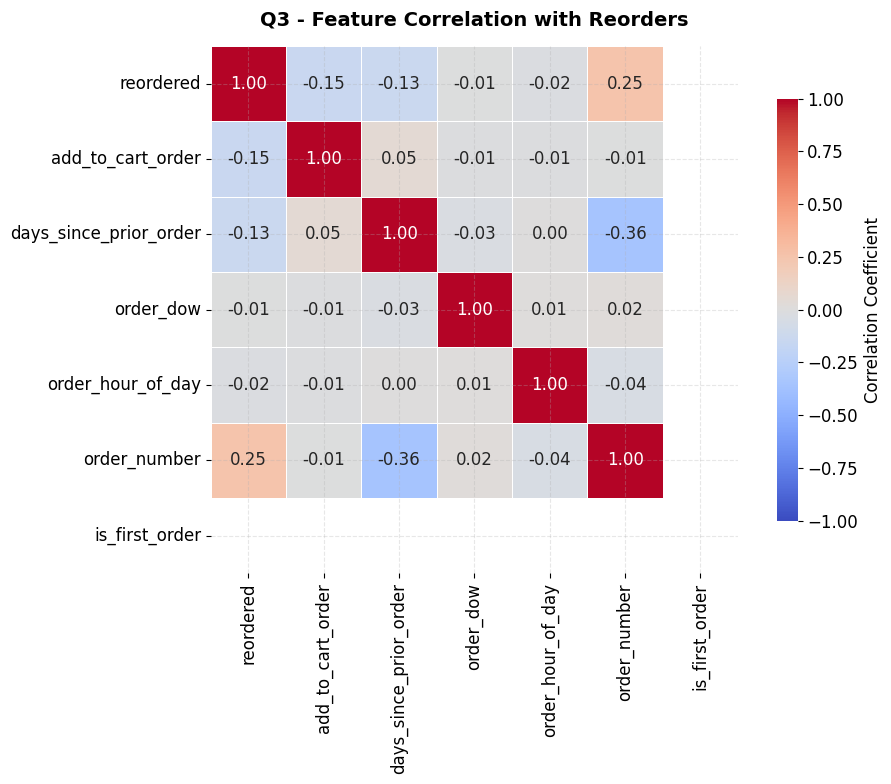

In [20]:
corelation_features = [
    'reordered',
    'add_to_cart_order',
    'days_since_prior_order',
    'order_dow',
    'order_hour_of_day',
    'order_number',
    'is_first_order'
]

correlation_matrix = df_reorders[corelation_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmax=1,
    vmin=-1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Q3 - Feature Correlation with Reorders', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q3_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q4 - What are the main customer profiles?

### 1. User profile dataframe

In [ ]:
user_profiles = df.groupby('user_id').agg(
    n_orders = ('order_id', 'nunique'),
    avg_basket_size = ('order_id', 'count'),  # a diviser pr la moyenne
    reorder_rate = ('reordered', 'mean'),
    avg_days_between_orders = ('days_since_prior_order', 'mean'),
    favorite_hour = ('order_hour_of_day', lambda x: x.mode()[0]),
    favorite_dow = ('order_dow', lambda x: x.mode()[0]),
    n_products = ('product_id', 'nunique'),
    n_aisles = ('aisle_id', 'nunique'),
    n_departments = ('department_id', 'nunique'),
)

### 2. Users profiles classification

In [ ]:
user_profiles["avg_basket_size"] = user_profiles["avg_basket_size"] / user_profiles["n_orders"]

p75_orders = user_profiles["n_orders"].quantile(0.75)
p75_basket = user_profiles["avg_basket_size"].quantile(0.75)
p75_diversity = user_profiles["n_departments"].quantile(0.75)
p75_reorder = user_profiles["reorder_rate"].quantile(0.75)

user_profiles['is_frequent'] = user_profiles['n_orders'] > p75_orders
user_profiles['is_big_basket'] = user_profiles['avg_basket_size'] > p75_basket
user_profiles['is_explorer'] = user_profiles['n_departments'] > p75_diversity
user_profiles['is_loyal'] = user_profiles['reorder_rate'] > p75_reorder

def assign_profile(row):
    if row['is_loyal'] and row['is_frequent']:
        return 'Client fidèle et fréquent'
    elif row['is_loyal']:
        return 'Routinier'
    elif row['is_big_basket']:
        return 'Gros panier'
    elif row['is_explorer']:
        return 'Explorateur'
    else:
        return 'Client occasionnel'


user_profiles['profile'] = user_profiles.apply(assign_profile, axis=1)

### 3. Visualize the profiles

In [ ]:
plt.figure(figsize=(8, 5))
user_profiles['profile'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Répartition des profils clients')
plt.xlabel('Profil')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Analysis**

**What are the main customer profiles?**

We identified **5 customer profiles** based on each user's order history:

- **Loyal & Frequent** — Orders often and consistently rebuys the same products. High reorder rate and high order count.

- **Routinier** — High reorder rate but orders less frequently. Buys the same products out of habit.

- **Big Basket** — Places fewer but larger orders. Above-average cart size per order.

- **Explorer** — Shops across many different departments. Low reorder rate and high product diversity.

- **Occasional** — Orders rarely, with small baskets and a low reorder rate. No strong purchasing pattern.

These profiles were defined using **p75 quantile thresholds** on features such as the number of orders, average basket size, reorder rate, and the number of departments shopped. This approach ensures the segments are balanced and relative to the actual distribution of the dataset.

## Q5 -  Which products are frequently bought together?

**Chart: Horizontal bar chart**

We group products by order, generate all product pairs, count their occurrences, and plot the top 10 pairs. The most frequent pairs appear at the top.

In [ ]:
orders = df.groupby("order_id")["product_name"].apply(list)

pairs = []
for order in orders:
    pairs += list(combinations(order, 2))

pair_counts = Counter(pairs)

pair_df = pd.DataFrame(pair_counts.items(), columns=["product_pair", "count"])
pair_df = pair_df.sort_values(by="count", ascending=False)

top10 = pair_df.head(10)

labels = [f"{a} & {b}" for a, b in top10["product_pair"]]

plt.figure(figsize=(10, 6))
plt.barh(labels, top10["count"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Number of orders")
plt.title("Top 10 Products bought together")
plt.savefig(os.path.join(figures_dir, 'q5_produts_bought_together.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:**<br>
The top 10 product pairs are led by banana & strawberry, showing that customers frequently buy these fruits together. This highlights a strong preference for complementary fresh produce. Retailers could use this insight for bundle promotions, recipe suggestions, or strategic placement to encourage larger baskets and repeat purchases.

## Q6 - Which department has the highest reorder rate?

**Chart: Horizontal bar chart**

We use `df_reorder` to compute the mean of `reordered` per department. A reorder rate close to 1 means customers almost always buy this department's products again.

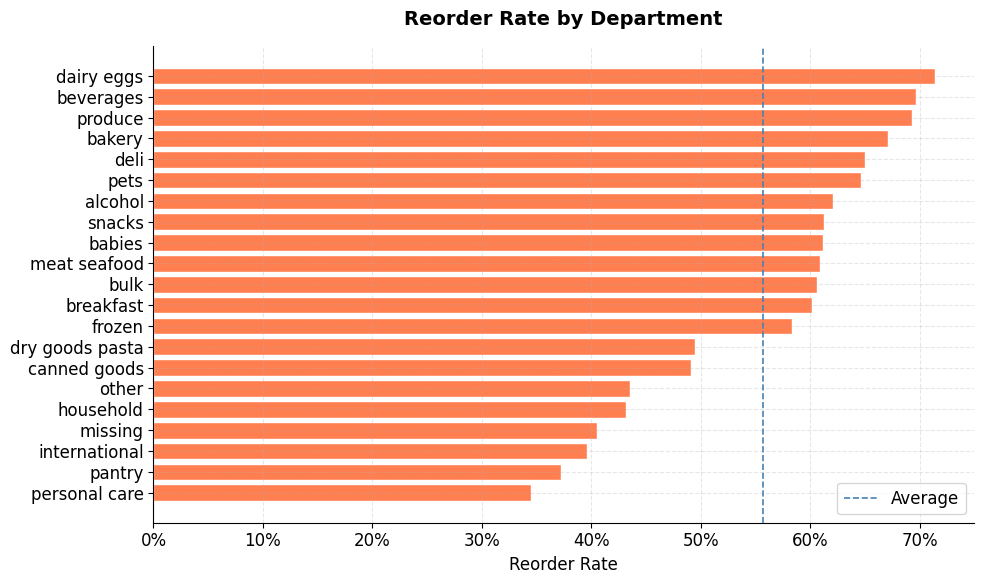

Top 5 Departments by Reorder Rate:
    department  reorder_rate
16        deli      0.650353
17      bakery      0.671187
18     produce      0.692611
19   beverages      0.696632
20  dairy eggs      0.713961
Average Reorder Rate: 0.5565635649284932
Personal Care Department Reorder Rate: 0.34461960246744344


In [21]:
reorder_by_department = (df_reorders
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    reorder_by_department['department'],
    reorder_by_department['reorder_rate'],
    color='coral',
    edgecolor='white'
)

ax.set_xlabel('Reorder Rate')
ax.set_title('Reorder Rate by Department', pad=15)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axvline(
    reorder_by_department['reorder_rate'].mean(),
    color='steelblue',
    linestyle='--',
    linewidth=1.2,
    label='Average'
)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q6_reorder_by_department.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Top 5 Departments by Reorder Rate:')
print(reorder_by_department.tail(5))

print("Average Reorder Rate:", reorder_by_department['reorder_rate'].mean())
print("Personal Care Department Reorder Rate:", reorder_by_department[reorder_by_department['department'] == 'personal care']['reorder_rate'].values[0])


**Analysis:**<br>
Dairy and eggs leads all departments with a ~72% reorder rate which make intuitive sense because milk, eggs and yogurt are weekly necessities that customers replenish on a predictable cycle. Beverage ~70% and produce ~69% follow closely, all three sitting well above the ~55% average (dashed line), confirming that perishable essentials drive the most loyal repeat behavior. Personal care sits at the bottom with ~34% nearly half the rate of dairy suggesting customers treat these as occasional purchases rather than regular staples, likely because products like shampoo or soap last much longer between repurchases. A retailer could use subscription-style reminders or bundle promotions to lift reorder rate in this department.

## Q7 - Link between days since last order and reorder rate?

**Chart: Scatter plot**

We compute the average reorder rate for each value of `days_since_prior_order`. A scatter plot reveals the shape of the relationship.

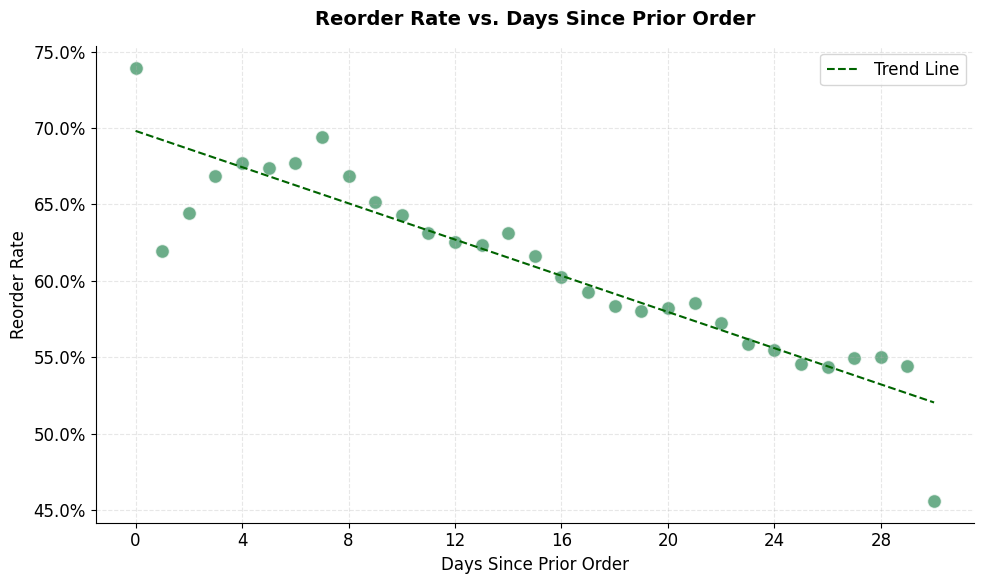

In [22]:
scatter_data = (df_reorders
    .groupby('days_since_prior_order')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    scatter_data['days_since_prior_order'],
    scatter_data['reorder_rate'],
    color='seagreen',
    edgecolor='white',
    s=100,
    alpha=0.7
)

# Trend line
z = np.polyfit(scatter_data['days_since_prior_order'], scatter_data['reorder_rate'], 1)
p = np.poly1d(z)
x_trend = np.linspace(
    scatter_data['days_since_prior_order'].min(),
    scatter_data['days_since_prior_order'].max(),
    100
)
ax.plot(
    x_trend,
    p(x_trend),
    color='darkgreen',
    linestyle='--',
    linewidth=1.5,
    label='Trend Line'
)

ax.set_xlabel('Days Since Prior Order')
ax.set_ylabel('Reorder Rate')
ax.set_title('Reorder Rate vs. Days Since Prior Order', pad=15)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q7_reorder_vs_days_since_prior.png'), dpi=300, bbox_inches='tight')
plt.show()

**Analysis:**<br>
The reorder rate shows a clear and consistent decline as days since the prior order increases, with the trend line confirming a steady linear decrease throughout the entire range. This suggests that customers who return quickly are in an established shopping routine, replenishing the same familiar products out of habit, while customers who wait longer are more likely browsing or exploring new items rather than restocking. A retailer should target customers with personalized "restock" reminders in the days following their last order, before the reorder intent starts to noticeably drop off.

## Q8 - What proportion of products is organic per department?

**Chart: Stacked horizontal bar chart**

We detect organic products by searching for "Organic" in the product name. A stacked bar shows both the organic and non-organic share simultaneously and it make proportions easy to compare across departments.

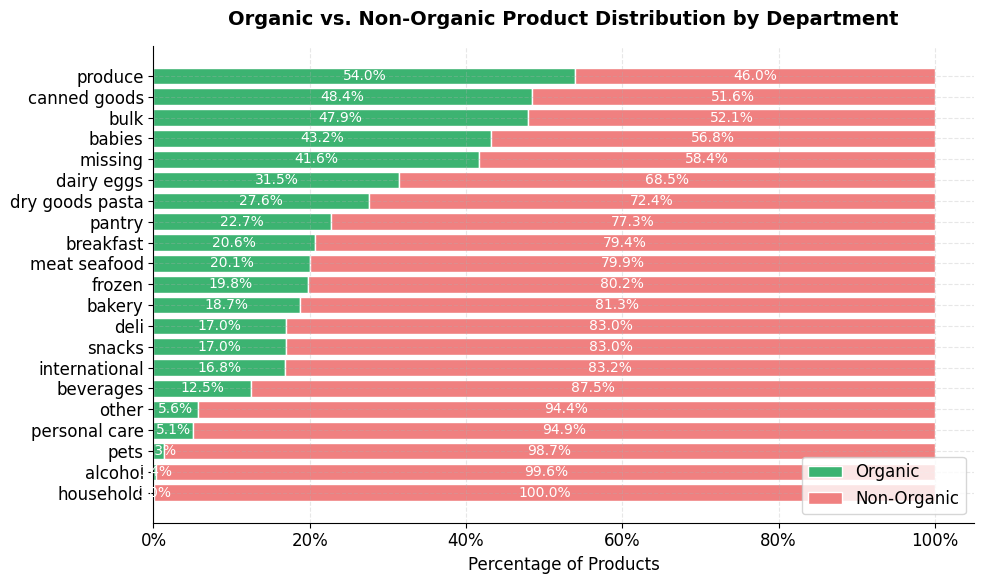

In [23]:
df_all['is_organic'] = df_all['product_name'].str.contains('organic', case=False, na=False).astype(int)

organic = (df_all
    .groupby('department')['is_organic']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'organic_count', 'count': 'total_count'})
)
organic['organic_percentage'] = organic['organic_count'] / organic['total_count']
organic['non_organic_percentage'] = 1 - organic['organic_percentage']
organic = organic.sort_values('organic_percentage')

fix, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    organic.index,
    organic['organic_percentage'],
    color='mediumseagreen',
    edgecolor='white',
    label='Organic'
)
ax.barh(
    organic.index,
    organic['non_organic_percentage'],
    left=organic['organic_percentage'],
    color='lightcoral',
    edgecolor='white',
    label='Non-Organic'
)

# Percentage organic and non organic labels
for i, (organic_pct, non_organic_pct) in enumerate(zip(organic['organic_percentage'], organic['non_organic_percentage'])):
    ax.text(organic_pct / 2, i, f'{organic_pct:.1%}', va='center', ha='center', color='white', fontsize=10)
    ax.text(organic_pct + non_organic_pct / 2, i, f'{non_organic_pct:.1%}', va='center', ha='center', color='white', fontsize=10)

ax.set_xlabel('Percentage of Products')
ax.set_title('Organic vs. Non-Organic Product Distribution by Department', pad=15)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q8_organic_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()


**Analysis:**<br>
Produce stands out as te most organic-oriented department with 54% of its products being organic, followed closely by canned goos 48.4% and bulk 47.9% reflecting strong consumer demand for organic options in fresh and natural food categories. At the other end, household 0%, alcohol 0.4% and pets 3% have virtually no organic presence, which is expected given the nature of these product categories. A retailer looking to grow its organic offering should focus investment on dairy eggs 31.5% and beverage 12.5%, where organic demand already exists but penetration remains relatively low compared to produce, these represent the highest-potential departments for organic line expansion.

## Q9 - Which item do customers add to their cart first ?

**Chart: frequency table and horizontal bar chart**

`add_to_cart_order == 1` identifies the first product placed in each cart. This reveal what customers instinctively reach for first.

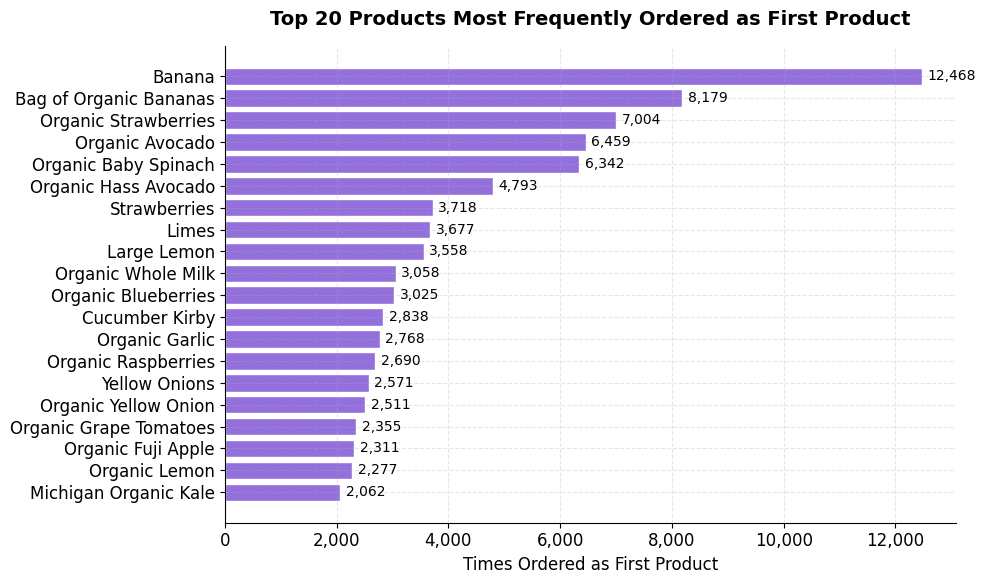

Top 5 Products Most Frequently Ordered as First Product:
             product_name  times_first_product
4    Organic Baby Spinach                 6342
3         Organic Avocado                 6459
2    Organic Strawberries                 7004
1  Bag of Organic Bananas                 8179
0                  Banana                12468


In [24]:
first_items = (df_all[df_all['is_first_order'] == 1]
    .groupby('product_name')['order_id']
    .count()
    .nlargest(top_n)
    .reset_index()
    .rename(columns={'order_id': 'times_first_product'})
    .sort_values('times_first_product')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    first_items['product_name'],
    first_items['times_first_product'],
    color='mediumpurple',
    edgecolor='white'
)

ax.set_xlabel('Times Ordered as First Product')
ax.set_title(f'Top {top_n} Products Most Frequently Ordered as First Product', pad=15)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2, f'{int(bar.get_width()):,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q9_first_product_bestsellers.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Top 5 Products Most Frequently Ordered as First Product:')
print(first_items.tail(5))

**Analysis:**<br>
Banana is by far the most common first item added to cart, place first more than 50% more often than the second product Bag of Organic Bananas, confirming it as the default. The top 20 here is nearly identical to the Q1 bestsellers list, the same fresh produce produce and organic items dominate both rankings, suggesting that the most purchased products are also the one customers think of first when starting their shop. A retailer should place these anchor products prominently at the top of the app homepage and search results, as capturing the customer's first add-to-cart moment with a familiar product significantly increases the likelihood they complete a full basket.

## Q10 - What factors correlate with cart size?

**Chart: Correlation heatmap + scatter plots**

Before building the cart size regressor, we examine which features correlate with `cart size`.

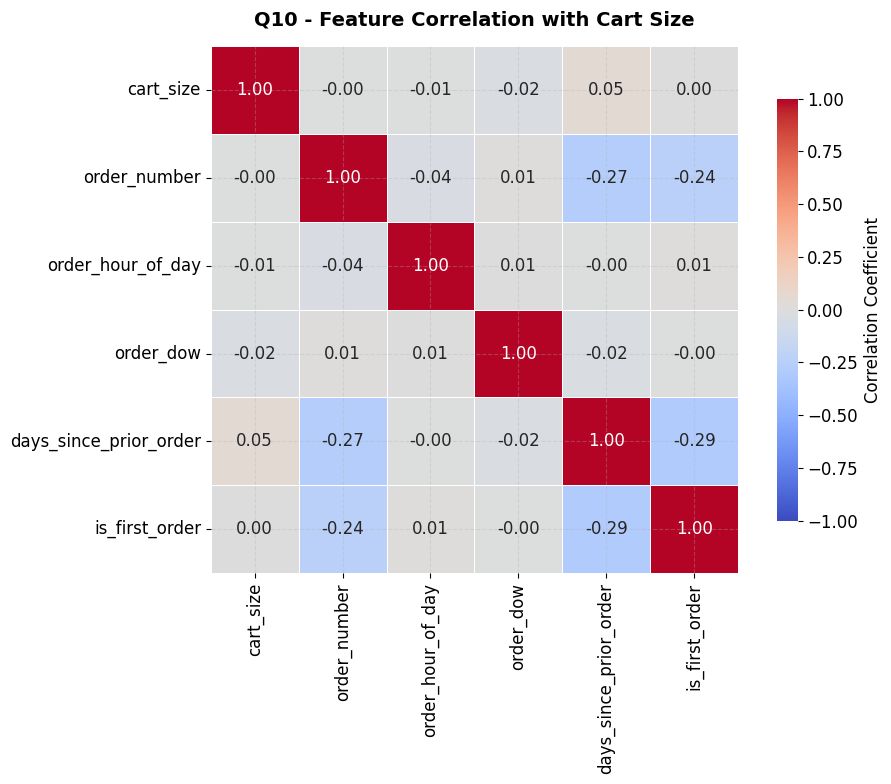

In [25]:
cart_size_order = (df_all
    .groupby('order_id')['product_id']
    .count()
    .reset_index()
    .rename(columns={'product_id': 'cart_size'})
)

order_level = df_all.drop_duplicates(subset='order_id')[
    ['order_id', 'user_id', 'order_number', 'order_hour_of_day', 'order_dow', 'days_since_prior_order', 'is_first_order']
].merge(cart_size_order, on='order_id', how='left')

correlation_features_10 = [
    'cart_size',
    'order_number',
    'order_hour_of_day',
    'order_dow',
    'days_since_prior_order',
    'is_first_order'
]

correlation_matrix_10 = order_level[correlation_features_10].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix_10,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmax=1,
    vmin=-1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Q10 - Feature Correlation with Cart Size', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q10_cart_size_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

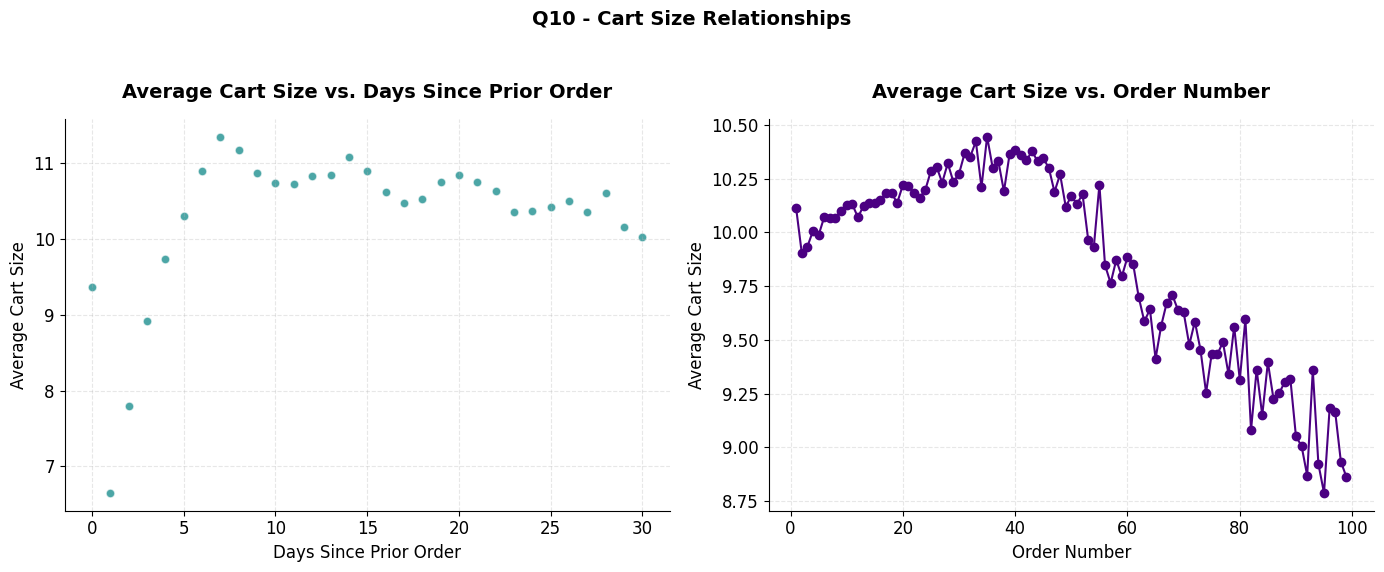

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Days since prior order vs. average cart size
cart_by_days = (order_level
    .groupby('days_since_prior_order')['cart_size']
    .mean()
    .reset_index()
)
ax[0].scatter(
    cart_by_days['days_since_prior_order'],
    cart_by_days['cart_size'],
    color='teal',
    edgecolor='white',
    s=40,
    alpha=0.7
)
ax[0].set_xlabel('Days Since Prior Order')
ax[0].set_ylabel('Average Cart Size')
ax[0].set_title('Average Cart Size vs. Days Since Prior Order', pad=15)

# Order number vs cart size
cart_by_order_number = (order_level
    .groupby('order_number')['cart_size']
    .mean()
    .reset_index()
)
ax[1].plot(
    cart_by_order_number['order_number'],
    cart_by_order_number['cart_size'],
    color='indigo',
    marker='o',
    linestyle='-',
    linewidth=1.5,
    markersize=6
)
ax[1].set_xlabel('Order Number')
ax[1].set_ylabel('Average Cart Size')
ax[1].set_title('Average Cart Size vs. Order Number', pad=15)

plt.suptitle('Q10 - Cart Size Relationships', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(figures_dir, 'q10_cart_size_relationships.png'), dpi=300, bbox_inches='tight')
plt.show()

## Q11 - What is the reorder rate by the hour of day?

**Chart: Line chart**

We compute the average reorder rate for each hour of the day. A line chart is appropriate here because hours are ordered and continuous, and we want to show trend over time.

We use `df_reorder` to exclude the first orders.

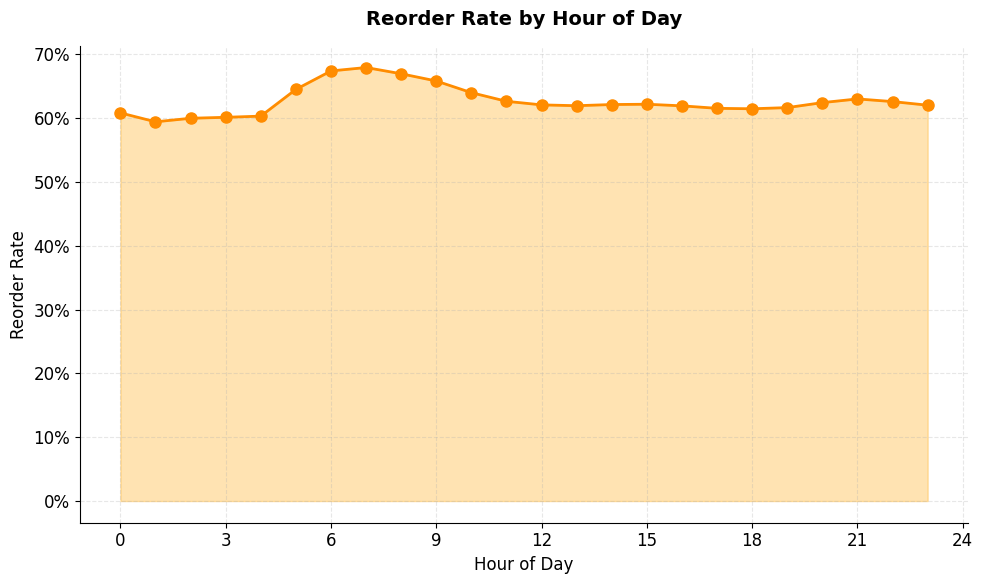

Peak reorder hour: 7:00 with reorder rate of 67.96%
Lowest reorder hour: 1:00 with reorder rate of 59.45%


In [27]:
reorder_by_hour = (df_reorders
    .groupby('order_hour_of_day')['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    reorder_by_hour['order_hour_of_day'],
    reorder_by_hour['reorder_rate'],
    marker='o',
    color='darkorange',
    linewidth=2,
    markersize=8
)
ax.fill_between(
    reorder_by_hour['order_hour_of_day'],
    reorder_by_hour['reorder_rate'],
    color='orange',
    alpha=0.3
)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Reorder Rate')
ax.set_title('Reorder Rate by Hour of Day', pad=15)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'q11_reorder_by_hour.png'), dpi=300, bbox_inches='tight')
plt.show()

peak_reorder_hour = reorder_by_hour.loc[reorder_by_hour['reorder_rate'].idxmax(), 'order_hour_of_day']
print(f'Peak reorder hour: {peak_reorder_hour}:00 with reorder rate of {reorder_by_hour["reorder_rate"].max():.2%}')

low_reorder_hour = reorder_by_hour.loc[reorder_by_hour['reorder_rate'].idxmin(), 'order_hour_of_day']
print(f'Lowest reorder hour: {low_reorder_hour}:00 with reorder rate of {reorder_by_hour["reorder_rate"].min():.2%}')

**Analysis:**<br>
The reorder rate peaks in the early morning hours around 6am–7am, suggesting that customers who shop at dawn are almost exclusively restocking familiar products rather than browsing, this is likely a habitual, routine-driven behaviour. The rate then gradually declines through the day and stabilises from midday onwards at a lower plateau, indicating that afternoon and evening shoppers are more exploratory. A retailer should leverage the early morning peak with automated "your usual items" cart suggestions or one-tap reorder notifications sent around 6am, when customers are most likely to place a habitual restock order.